In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# 自动定位项目根目录：notebook 位于 notes/ 下，向上一级即为项目根
cwd = os.getcwd()
if os.path.basename(cwd) == 'notes':
    os.chdir('..')
print('当前工作目录:', os.getcwd())

当前工作目录: D:\github\prediction


In [2]:
#mlp模型 （2）
import torch
from torch import nn
from d2l import torch as d2l

# ============================================================
# 1. 加载数据 (1141A 普陀站) + 预处理 + 80/15/5 分割
# ============================================================
import numpy as np
df_raw = pd.read_csv('data/ShanghaiPM_full.csv', na_values='NA')

# 预处理 (与 xg_boost(3) 一致: 时间轴补齐 → 插值 → pm_ave log)
WEATHER_COLS = ['DEWP', 'HUMI', 'PRES', 'TEMP', 'Iws', 'precipitation', 'Iprec']
df_raw['datetime'] = pd.to_datetime(
    {'year': df_raw['year'], 'month': df_raw['month'], 'day': df_raw['day'], 'hour': df_raw['hour']})
df_raw = df_raw.set_index('datetime').sort_index()
full_idx = pd.date_range(df_raw.index[0], df_raw.index[-1], freq='1h')
df_raw = df_raw.reindex(full_idx)
df_raw[WEATHER_COLS] = df_raw[WEATHER_COLS].interpolate(method='time').bfill().ffill()
pm_cols = ['PM_Jingan', 'PM_US Post', 'PM_Xuhui']
df_raw['pm_ave'] = df_raw[pm_cols].mean(axis=1)
df_raw['pm_ave'] = df_raw['pm_ave'].interpolate(method='time', limit=168)
df_raw = df_raw.dropna(subset=['pm_ave'])
df_raw['pm_ave'] = np.log1p(df_raw['pm_ave'])  # log 空间 (与 xg_boost 一致)

# 80/15/5 分割
n_total = len(df_raw)
n_train = int(n_total * 0.80)
n_val   = int(n_total * 0.15)
df_train_full = df_raw.iloc[:n_train + n_val].copy()  # 80%+15% = 95% (含验证)
df_test  = df_raw.iloc[n_train + n_val:].copy()       # 5% 测试

# 提取 pm_ave 时间序列
x_train_full = torch.tensor(df_train_full['pm_ave'].values, dtype=torch.float32)
x_test  = torch.tensor(df_test['pm_ave'].values, dtype=torch.float32)
print(f'训练+验证序列: {len(x_train_full)}  |  测试序列: {len(x_test)} (5%)')

# ============================================================
# 2. 标准化 (用训练集统计量)
# ============================================================
mean, std = x_train_full.mean(), x_train_full.std()
x_train_full = (x_train_full - mean) / std
x_test  = (x_test  - mean) / std

# ============================================================
# 3. 构建自回归特征 (用过去 tau 步预测下一步)
# ============================================================
tau = 24  # 回看窗口

# 从 x_train_full 中切出 80% 训练 + 15% 验证
split_idx = int(len(x_train_full) * (n_train / (n_train + n_val)))
x_train_split = x_train_full[:split_idx].clone()
x_val = x_train_full[split_idx:].clone()
print(f'训练序列: {len(x_train_split)}  |  验证序列: {len(x_val)}  |  测试序列: {len(x_test)} (训练时不碰)')

# 构建训练特征
n_train = len(x_train_split)
features_train = torch.zeros((n_train - tau, tau))
for i in range(tau):
    features_train[:, i] = x_train_split[i: n_train - tau + i]
labels_train = x_train_split[tau:].reshape((-1, 1))

# 构建验证特征
n_val = len(x_val)
features_val = torch.zeros((n_val - tau, tau))
for i in range(tau):
    features_val[:, i] = x_val[i: n_val - tau + i]
labels_val = x_val[tau:].reshape((-1, 1))

# 数据迭代器 (官方 d2l.load_array: is_train=True 打乱, False 不打乱)
batch_size = 16
train_iter = d2l.load_array((features_train, labels_train), batch_size, is_train=True)
val_iter   = d2l.load_array((features_val, labels_val), batch_size, is_train=False)

# ============================================================
# 4. 定义网络 + 损失 (与 sequence.ipynb 完全一致)
# ============================================================
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)

def get_net():
    net = nn.Sequential(nn.Linear(tau, 128), nn.ReLU(), nn.Linear(128, 1))
    net.apply(init_weights)
    return net

loss = nn.MSELoss(reduction='none')

# ============================================================
# 5. 训练 (只用 train 数据, 与 sequence.ipynb 一致)
# ============================================================
def train(net, train_iter, val_iter, loss, epochs, lr, weight_decay=0.002):
    trainer = torch.optim.Adam(net.parameters(), lr)
    for epoch in range(epochs):
        net.train()
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            # L2 正则化: 对所有权重参数求平方和, 抑制过拟合
            l2_reg = sum(torch.sum(param ** 2) for param in net.parameters())
            (l.sum() + weight_decay * l2_reg).backward()
            trainer.step()
        # 同时打印训练损失和验证损失 (验证集不参与梯度更新)
        train_loss = d2l.evaluate_loss(net, train_iter, loss)
        val_loss   = d2l.evaluate_loss(net, val_iter, loss)
        print(f'epoch {epoch + 1}, train loss: {train_loss:f}, val loss: {val_loss:f}')

net = get_net()
train(net, train_iter, val_iter, loss, 50, 0.002)

# ============================================================
# 6. 测试: 前 24 条公开 (作为起点), 剩余多步预测
#    算法只能看到前 24 条真实值, 之后用自己的预测值作为输入
# ============================================================
n_public = 24  # 前 24 条测试数据是公开的

# 初始化预测数组 (标准化空间), 前 24 条填入真实值
test_preds = torch.zeros(len(x_test))
test_preds[:n_public] = x_test[:n_public]

# 第 24 条起: 多步预测 (用预测值替代未知的真实值作为输入)
for i in range(n_public, len(x_test)):
    test_preds[i] = net(test_preds[i - tau:i].reshape((1, -1)))

# 反标准化回原始量纲 (μg/m³)
preds_all  = (test_preds * std + mean).detach()  # 全部 401 点 (前 24 = 真实)
actual_all = (x_test   * std + mean).detach()     # 全部 401 点真实值

print(f'\n公开起点: 前 {n_public} 条  |  预测区间: 第 {n_public+1} ~ {len(x_test)} 条 (共 {len(x_test)-n_public} 条)')

训练+验证序列: 66621  |  测试序列: 3507 (5%)
训练序列: 56102  |  验证序列: 10519  |  测试序列: 3507 (训练时不碰)


D:\conda_envs\d2l\lib\site-packages\d2l\torch.py:3179: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  self.data = [a + float(b) for a, b in zip(self.data, args)]


epoch 1, train loss: 0.107673, val loss: 0.168974


epoch 2, train loss: 0.102192, val loss: 0.158007


epoch 3, train loss: 0.102095, val loss: 0.156529


...

epoch 47, train loss: 0.101376, val loss: 0.157775


epoch 48, train loss: 0.100806, val loss: 0.156524


epoch 49, train loss: 0.104503, val loss: 0.157638


epoch 50, train loss: 0.103349, val loss: 0.158882



公开起点: 前 24 条  |  预测区间: 第 25 ~ 3507 条 (共 3483 条)


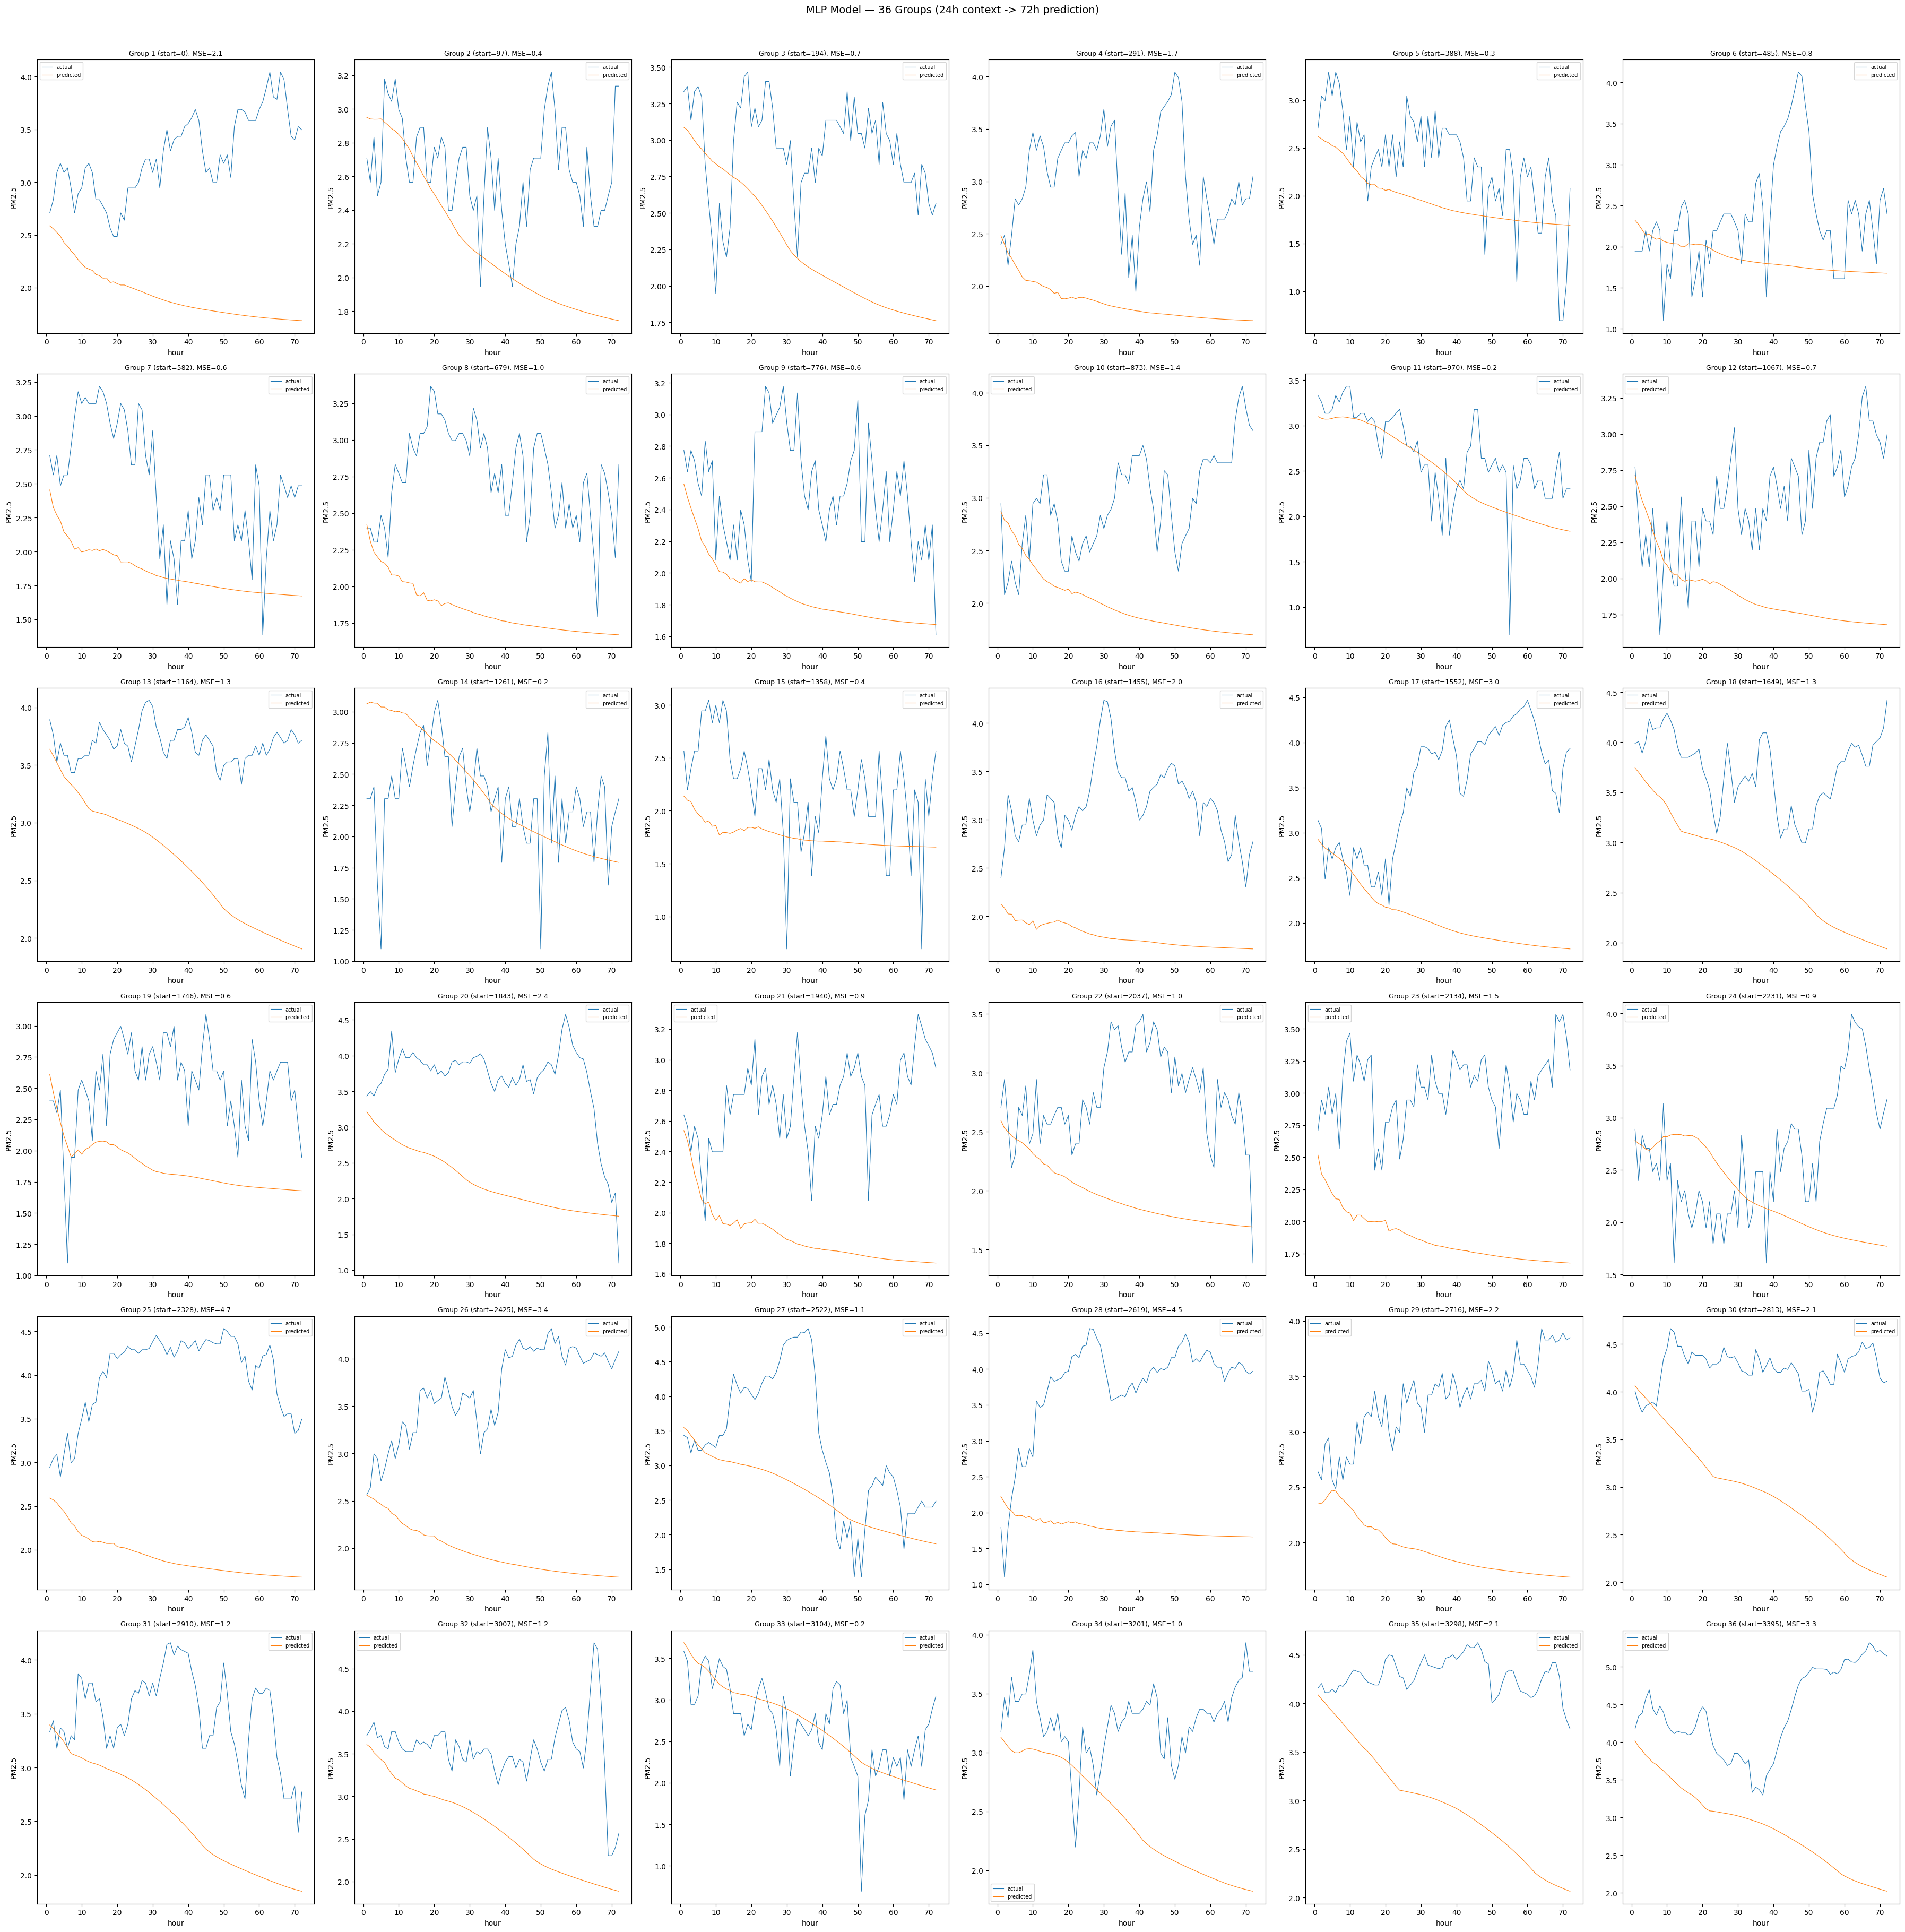


=== 36 组 MSE 汇总 ===
  Group  1: MSE = 2.05
  Group  2: MSE = 0.37
  Group  3: MSE = 0.70
  Group  4: MSE = 1.66
  Group  5: MSE = 0.32
  Group  6: MSE = 0.77
  Group  7: MSE = 0.56
  Group  8: MSE = 0.95
  Group  9: MSE = 0.55
  Group 10: MSE = 1.38
  Group 11: MSE = 0.18
  Group 12: MSE = 0.71
  Group 13: MSE = 1.30
  Group 14: MSE = 0.23
  Group 15: MSE = 0.40
  Group 16: MSE = 2.04
  Group 17: MSE = 2.96
  Group 18: MSE = 1.30
  Group 19: MSE = 0.60
  Group 20: MSE = 2.38
  Group 21: MSE = 0.93
  Group 22: MSE = 0.97
  Group 23: MSE = 1.50
  Group 24: MSE = 0.88
  Group 25: MSE = 4.69
  Group 26: MSE = 3.37
  Group 27: MSE = 1.10
  Group 28: MSE = 4.52
  Group 29: MSE = 2.21
  Group 30: MSE = 2.08
  Group 31: MSE = 1.17
  Group 32: MSE = 1.21
  Group 33: MSE = 0.18
  Group 34: MSE = 1.00
  Group 35: MSE = 2.06
  Group 36: MSE = 3.29

平均 MSE = 1.46


In [3]:
# ============================================================
# 36 组评估: 每组 24h 上下文 + 72h 预测 (MLP 模型)
# MLP 只用 pm_ave 单通道, 纯自回归多步预测
# ============================================================
import numpy as np

N_GROUPS = 36
N_CONTEXT = 24
N_PREDICT = 72
STRIDE = (len(df_test) - N_CONTEXT - N_PREDICT) // (N_GROUPS - 1)

# 使用 cell 1 中已定义的: net, x_test(标准化), mean, std, tau
all_mses = []
fig, axes = plt.subplots(6, 6, figsize=(36, 36))
axes = axes.flatten()

for g in range(N_GROUPS):
    start = g * STRIDE
    # pm_series: 标准化空间的 96 小时 pm_ave (前 24 为上下文真实值)
    pm_series = np.zeros(N_CONTEXT + N_PREDICT)
    pm_series[:N_CONTEXT] = x_test[start:start + N_CONTEXT].numpy()

    # 多步预测 72 小时 (纯自回归, 无外生变量)
    with torch.no_grad():
        for i in range(N_PREDICT):
            # 回看窗口: 局部位置 [i, i+tau), 共 tau=24 个 pm_ave 值
            window = torch.zeros(tau)
            for t in range(tau):
                window[t] = pm_series[i + t]
            pm_series[N_CONTEXT + i] = net(window.reshape(1, -1)).item()

    # 反标准化回原始量纲
    preds = pm_series[N_CONTEXT:] * std.item() + mean.item()
    actual = df_test['pm_ave'].values[start + N_CONTEXT:start + N_CONTEXT + N_PREDICT]

    mse = ((preds - actual) ** 2).mean()
    all_mses.append(mse)

    ax = axes[g]
    hours = np.arange(1, N_PREDICT + 1)
    ax.plot(hours, actual, linewidth=0.8, label='actual')
    ax.plot(hours, preds, linewidth=0.8, label='predicted')
    ax.set_title(f'Group {g+1} (start={start}), MSE={mse:.1f}', fontsize=9)
    ax.legend(fontsize=7)
    ax.set_xlabel('hour')
    ax.set_ylabel('PM2.5')

plt.suptitle(f'MLP Model — {N_GROUPS} Groups (24h context -> 72h prediction)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f'\n=== {N_GROUPS} 组 MSE 汇总 ===')
for g, mse in enumerate(all_mses):
    print(f'  Group {g+1:2d}: MSE = {mse:.2f}')
print(f'\n平均 MSE = {np.mean(all_mses):.2f}')